In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import folium

import os
os.chdir("./..")

pd.set_option("display.max_columns", None)

# Loading dataset

In [2]:
weather_path = Path("data/weather/all_weather_by_hour_2023-2025_v1.csv")
weather_raw = pd.read_csv(weather_path)
weather = weather_raw.copy()

weather.head()

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunriseEpoch,day_sunset,day_sunsetEpoch,day_moonphase,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_preciptype,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations
0,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,00:00:00,1645653600,2.4,-1.6,89.18,0.8,0.0,0.0,0.1,0.2,['snow'],31.3,15.5,275.6,1020.0,0.0,91.5,0.0,NaN,0.0,Overcast,snow,obs,remote
1,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,01:00:00,1645657200,2.4,-1.5,87.90,0.6,0.0,0.0,0.0,0.2,['snow'],27.7,14.8,280.3,1021.0,0.2,88.2,0.0,NaN,0.0,Partially cloudy,fog,obs,remote
2,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,02:00:00,1645660800,2.9,-0.8,88.58,1.2,0.0,0.0,0.0,0.1,['snow'],29.2,14.4,310.0,1022.0,10.0,100.0,NaN,NaN,NaN,Overcast,cloudy,obs,33177099999
3,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,03:00:00,1645664400,2.3,-1.3,86.63,0.3,0.0,0.0,0.0,0.1,['snow'],23.8,13.3,295.1,1021.0,0.1,92.0,0.0,NaN,0.0,Overcast,fog,obs,remote
4,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,04:00:00,1645668000,1.9,-1.8,87.85,0.1,0.0,0.0,0.0,0.1,['snow'],24.5,13.3,305.8,1021.0,0.0,93.8,0.0,NaN,0.0,Overcast,cloudy,obs,remote


# Data Preparation

In [4]:
weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 608304 entries, 0 to 608303
Data columns (total 65 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   city_latitude         608304 non-null  float64
 1   city_longitude        608304 non-null  float64
 2   city_resolvedAddress  608304 non-null  str    
 3   city_address          608304 non-null  str    
 4   city_timezone         608304 non-null  str    
 5   city_tzoffset         608304 non-null  float64
 6   day_datetime          608304 non-null  str    
 7   day_datetimeEpoch     608304 non-null  int64  
 8   day_tempmax           608304 non-null  float64
 9   day_tempmin           608304 non-null  float64
 10  day_temp              608304 non-null  float64
 11  day_feelslikemax      608304 non-null  float64
 12  day_feelslikemin      608304 non-null  float64
 13  day_feelslike         608304 non-null  float64
 14  day_dew               608304 non-null  float64
 15  day_humidit

In [5]:
weather['day_datetime'] = pd.to_datetime(weather['day_datetime'])
weather['hour_datetime'] = pd.to_datetime(weather['hour_datetime'])
weather['real_hour_datetime'] = pd.to_datetime(
    weather['day_datetime'].dt.date.astype(str) + ' ' + weather['hour_datetime'].dt.time.astype(str)
)
weather['city_clean'] = weather['city_address'].astype(str).apply(lambda x: x.split(',')[0].strip())

weather = weather[(weather['hour_temp'] >= -40) & (weather['hour_temp'] <= 50)]
weather['hour_conditions'] = weather['hour_conditions'].fillna('unknown')
weather['month'] = weather['day_datetime'].dt.month

weather.describe()

C:\Users\Георгій\AppData\Local\Temp\ipykernel_22884\853810239.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weather['hour_datetime'] = pd.to_datetime(weather['hour_datetime'])


,city_latitude,city_longitude,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunriseEpoch,day_sunsetEpoch,day_moonphase,hour_datetime,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,real_hour_datetime,month
count,608302.000000,608302.000000,608302.0,608302,6.083020e+05,608302.000000,608302.000000,608302.000000,608302.000000,608302.000000,608302.000000,608302.000000,608302.000000,608302.000000,608302.000000,608302.000000,608302.000000,608302.000000,608302.000000,608302.000000,608302.000000,608302.000000,608302.000000,552950.000000,607750.000000,607750.000000,607750.000000,6.083020e+05,6.083020e+05,608302.000000,608302,6.083020e+05,608302.000000,608302.000000,608302.000000,608302.000000,608200.000000,608302.000000,608302.000000,608302.000000,608302.000000,608302.000000,608302.000000,608302.000000,331844.000000,608302.000000,603966.000000,521041.000000,603966.000000,608302,608302.000000
mean,49.143242,30.142497,2.0,2023-08-28 12:36:48.923857,1.693217e+09,15.203159,6.254071,10.721059,14.287172,4.267389,9.254483,5.285641,72.891235,2.095635,53.534100,6.553083,0.121132,0.598358,34.879073,18.545723,191.158486,1016.920925,64.812639,14.917177,141.952883,12.242435,4.806068,1.693240e+09,1.693284e+09,0.489195,2026-03-15 11:29:59.887555,1.693258e+09,10.719408,9.252922,72.891327,5.283818,0.087358,6.552831,0.005045,0.598143,23.769980,11.399957,189.829984,1016.918389,17.010538,64.811146,142.722751,0.595018,1.413907,2023-08-29 00:06:48.811411,6.498973
min,46.472500,22.285100,2.0,2022-02-24 00:00:00,1.645654e+09,-14.300000,-50.300000,-17.500000,-21.800000,-50.300000,-27.100000,-20.700000,23.300000,0.000000,0.000000,0.000000,0.000000,0.000000,6.100000,2.500000,0.000000,981.600000,0.000000,0.000000,0.000000,0.000000,0.000000,1.645676e+09,1.645715e+09,0.000000,2026-03-15 00:00:00,1.645654e+09,-22.500000,-30.600000,8.460000,-25.900000,0.000000,0.000000,0.000000,0.000000,0.700000,0.000000,0.000000,973.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2022-02-24 00:00:00,1.000000
25%,48.292400,25.935500,2.0,2022-11-26 00:00:00,1.669414e+09,5.900000,-0.200000,2.800000,3.800000,-3.800000,-0.100000,-0.300000,62.400000,0.000000,0.000000,0.000000,0.000000,0.000000,26.600000,14.000000,98.200000,1011.500000,43.900000,9.900000,51.200000,4.400000,2.000000,1.669441e+09,1.669472e+09,0.250000,2026-03-15 05:15:00,1.669457e+09,2.400000,-0.300000,59.310000,-0.400000,0.000000,0.000000,0.000000,0.000000,14.800000,7.200000,98.000000,1011.200000,10.000000,30.000000,0.000000,0.000000,0.000000,2022-11-26 12:00:00,3.000000
50%,49.416800,30.737100,2.0,2023-08-29 00:00:00,1.693256e+09,15.100000,6.100000,10.600000,15.100000,4.200000,9.900000,5.300000,74.200000,0.100000,100.000000,4.170000,0.000000,0.000000,33.800000,18.000000,195.600000,1016.500000,70.700000,12.500000,129.400000,11.200000,5.000000,1.693277e+09,1.693326e+09,0.500000,2026-03-15 11:00:00,1.693260e+09,10.200000,10.200000,77.430000,5.300000,0.000000,0.000000,0.000000,0.000000,22.300000,10.800000,191.900000,1016.600000,15.800000,80.000000,5.600000,0.100000,0.000000,2023-08-29 01:00:00,7.000000
75%,50.253600,34.551700,2.0,2024-05-30 00:00:00,1.717016e+09,24.600000,13.200000,18.800000,24.600000,13.200000,18.800000,11.500000,84.800000,1.092000,100.000000,8.330000,0.000000,0.000000,41.400000,22.000000,287.000000,1022.000000,90.600000,20.000000,226.800000,19.600000,7.000000,1.717035e+09,1.717092e+09,0.750000,2026-03-15 17:00:00,1.717062e+09,18.400000,18.400000,89.050000,11.500000,0.000000,0.000000,0.000000,0.000000,31.0

No missing values

# EDA
## Build histplot for temperature

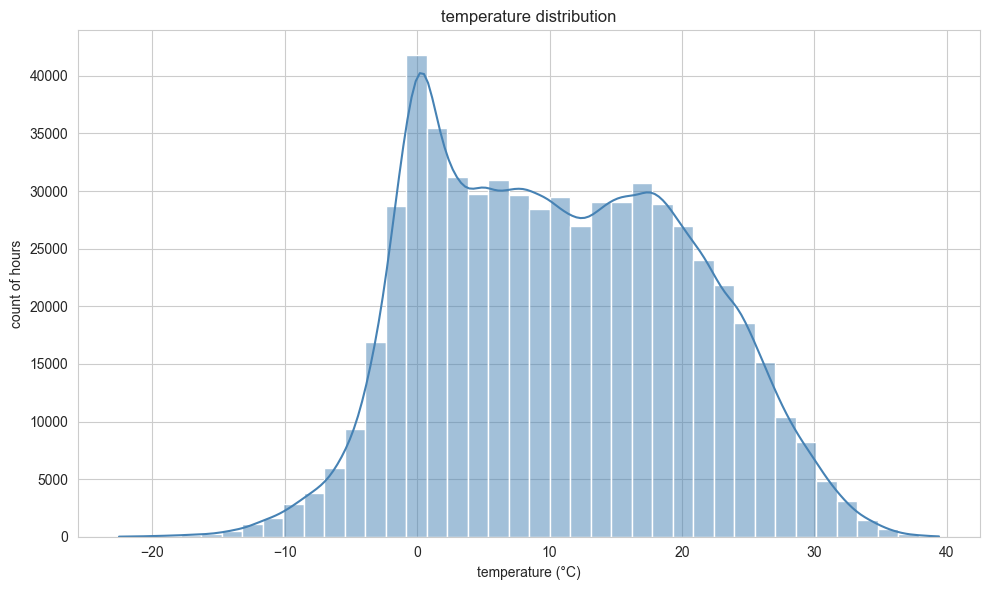

In [6]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(
    data=weather,
    x="hour_temp", 
    bins=40,
    kde=True,
    color="steelblue"
)

plt.xlabel("temperature (°C)")
plt.ylabel("count of hours")
plt.title("temperature distribution")
plt.tight_layout()
plt.show()

- Temperature distribution is close to normal but slightly skewed.
- Most frequent temperatures are around 0-5°C and 15-20°C.

## Daily average temperature with spikes

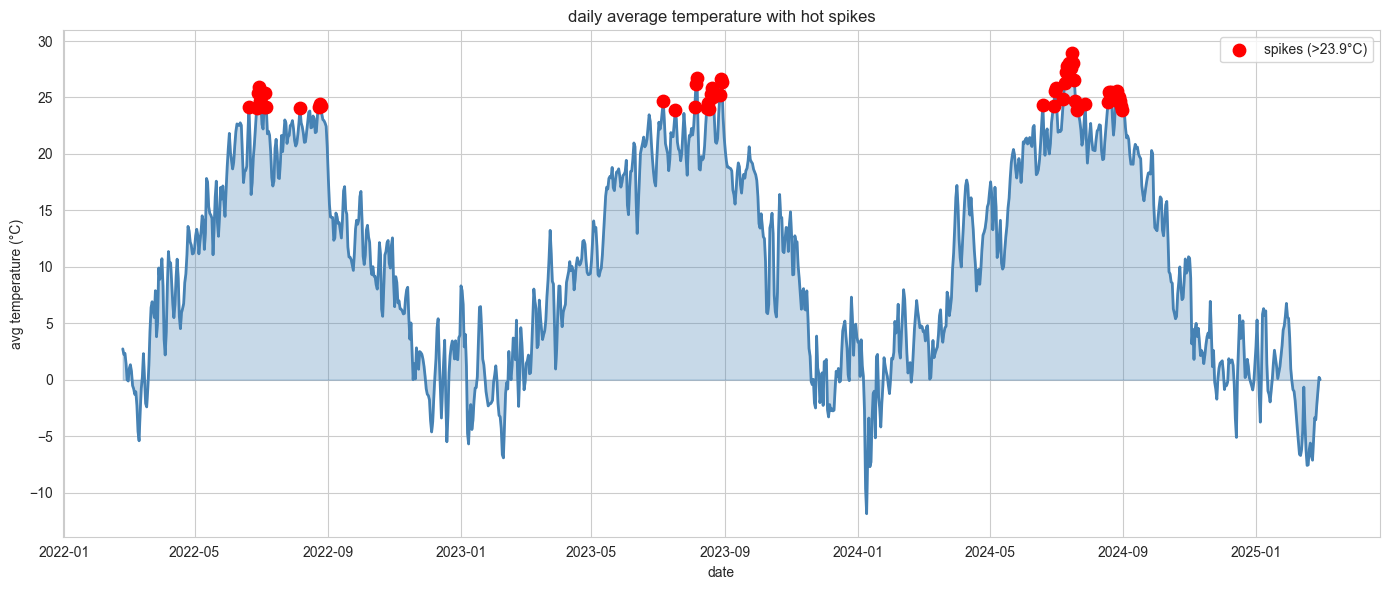

In [7]:
temp_daily = weather.groupby(weather['day_datetime'].dt.date)['hour_temp'].mean().reset_index()
temp_daily['day_datetime'] = pd.to_datetime(temp_daily['day_datetime'])

plt.figure(figsize=(14, 6))

plt.plot(temp_daily['day_datetime'], temp_daily['hour_temp'], linewidth=2, color='steelblue')
plt.fill_between(temp_daily['day_datetime'], temp_daily['hour_temp'], alpha=0.3, color='steelblue')

spike_threshold = temp_daily['hour_temp'].quantile(0.95)
spikes = temp_daily[temp_daily['hour_temp'] > spike_threshold]

plt.scatter(spikes['day_datetime'], spikes['hour_temp'], color='red', s=80, zorder=5, 
            label=f'spikes (>{spike_threshold:.1f}°C)')

plt.title("daily average temperature with hot spikes")
plt.xlabel("date")
plt.ylabel("avg temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()

- Clear seasonality over the years.
- Red dots represent the hottest 5% of days.

## Heatmap by month and year

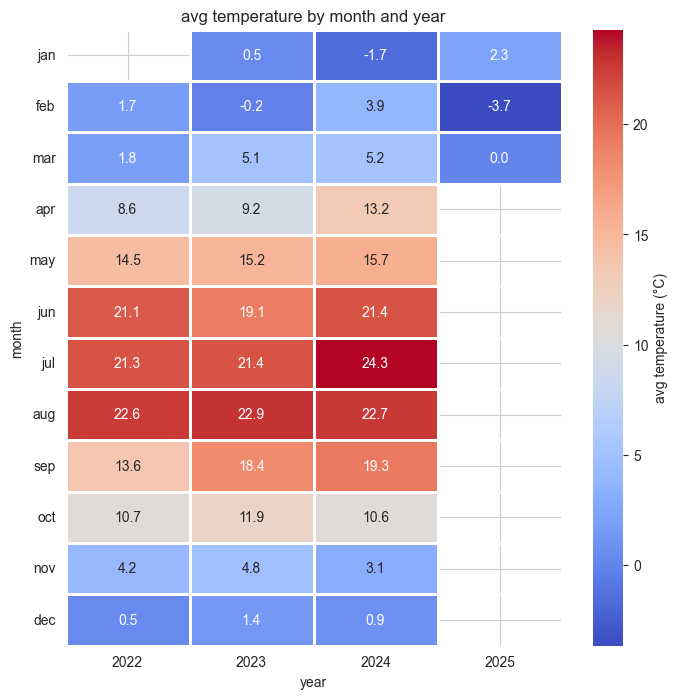

In [8]:
temp = weather[['day_datetime', 'hour_temp']].copy()
temp['month'] = temp['day_datetime'].dt.month
temp['year'] = temp['day_datetime'].dt.year

temp_pivot = temp.groupby(["year", "month"])['hour_temp'].mean().reset_index()
temp_pivot = temp_pivot.pivot(index="month", columns="year", values="hour_temp")

month_names = {
 1: 'jan', 2: 'feb', 3: 'mar', 4: 'apr', 5: 'may', 6: 'jun',
 7: 'jul', 8: 'aug', 9: 'sep', 10: 'oct', 11: 'nov', 12: 'dec'
}
temp_pivot = temp_pivot.rename(index=month_names)

plt.figure(figsize=(8, 8))
sns.heatmap(
    data=temp_pivot,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    linewidths=1,
    cbar_kws={'label': 'avg temperature (°C)'}
)

plt.title("avg temperature by month and year")
plt.xlabel("year")
plt.ylabel("month")
plt.yticks(rotation=0)
plt.show()

## Ridgeline plot for monthly distribution

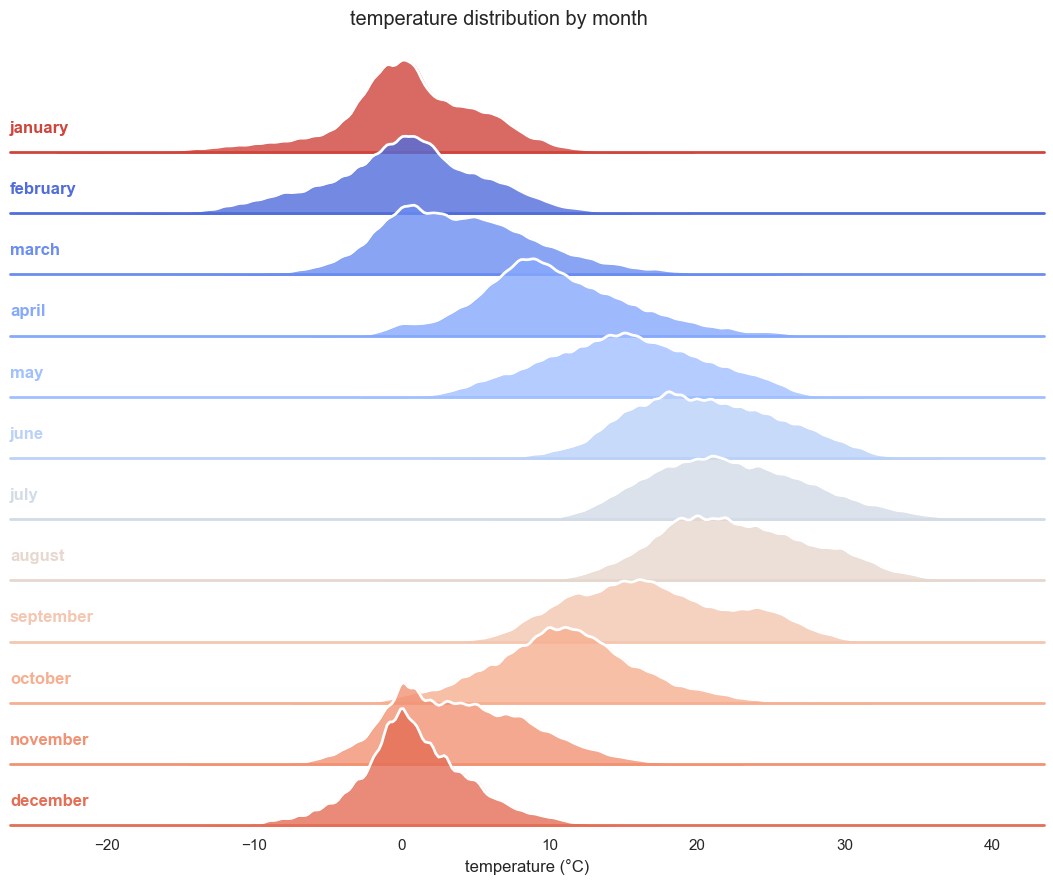

In [9]:
weather['month_name'] = weather['day_datetime'].dt.strftime('%B').str.lower()
months_order = ['january', 'february', 'march', 'april', 'may', 'june', 
                'july', 'august', 'september', 'october', 'november', 'december']

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

pal = sns.color_palette("coolwarm", 12)
g = sns.FacetGrid(weather, row="month_name", hue="month_name", aspect=15, height=0.75, palette=pal, row_order=months_order)

g.map(sns.kdeplot, "hour_temp", bw_adjust=.5, clip_on=False, fill=True, alpha=0.8, linewidth=1.5)
g.map(sns.kdeplot, "hour_temp", clip_on=False, color="w", lw=2, bw_adjust=.5)
g.map(plt.axhline, y=0, lw=2, clip_on=False)

def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes)
g.map(label, "hour_temp")

g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

plt.subplots_adjust(hspace=-0.5)
g.fig.suptitle('temperature distribution by month')
g.set_axis_labels("temperature (°C)", "")
plt.show()

sns.set_style("whitegrid")

## Bloomberg style stripes

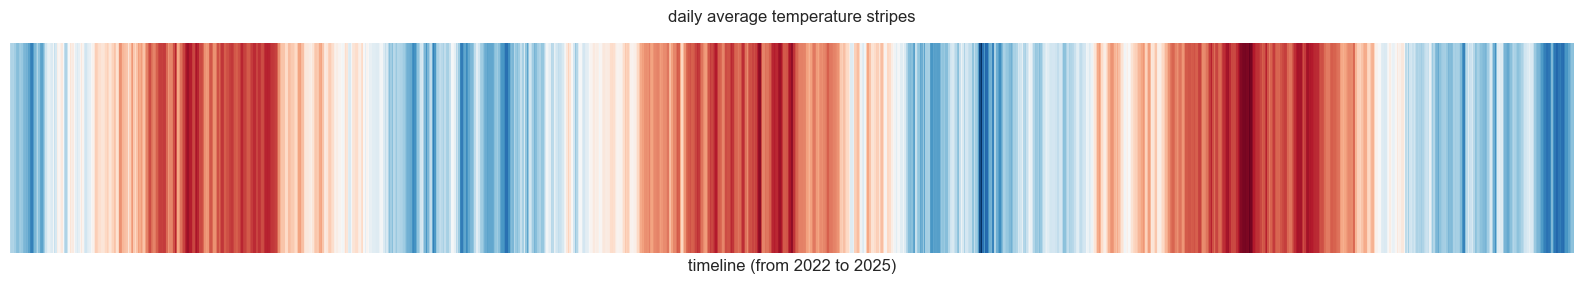

In [10]:
daily_temp = weather.groupby(weather['day_datetime'].dt.date)['hour_temp'].mean()

plt.figure(figsize=(16, 3))
sns.heatmap(
    [daily_temp.values], 
    cmap='RdBu_r', 
    cbar=False, 
    yticklabels=False,
    xticklabels=False
)

plt.title("daily average temperature stripes", pad=15)
plt.xlabel("timeline (from 2022 to 2025)")
plt.tight_layout()
plt.show()

## Interactive map

In [11]:
city_stats = weather.groupby(['city_clean', 'city_latitude', 'city_longitude'])['hour_temp'].mean().reset_index()

m = folium.Map(location=[48.3794, 31.1656], zoom_start=6, tiles="CartoDB positron")

for idx, row in city_stats.iterrows():
    marker_color = "#e74c3c" if row['hour_temp'] > 10 else "#3498db"
    
    folium.CircleMarker(
        location=[row['city_latitude'], row['city_longitude']],
        radius=12,
        popup=f"<b>{row['city_clean']}</b><br>avg temp: {row['hour_temp']:.1f}°C",
        tooltip=row['city_clean'],
        color=marker_color,
        fill=True,
        fill_color=marker_color,
        fill_opacity=0.7,
        weight=2
    ).add_to(m)

display(m)

## Density of temperature vs humidity

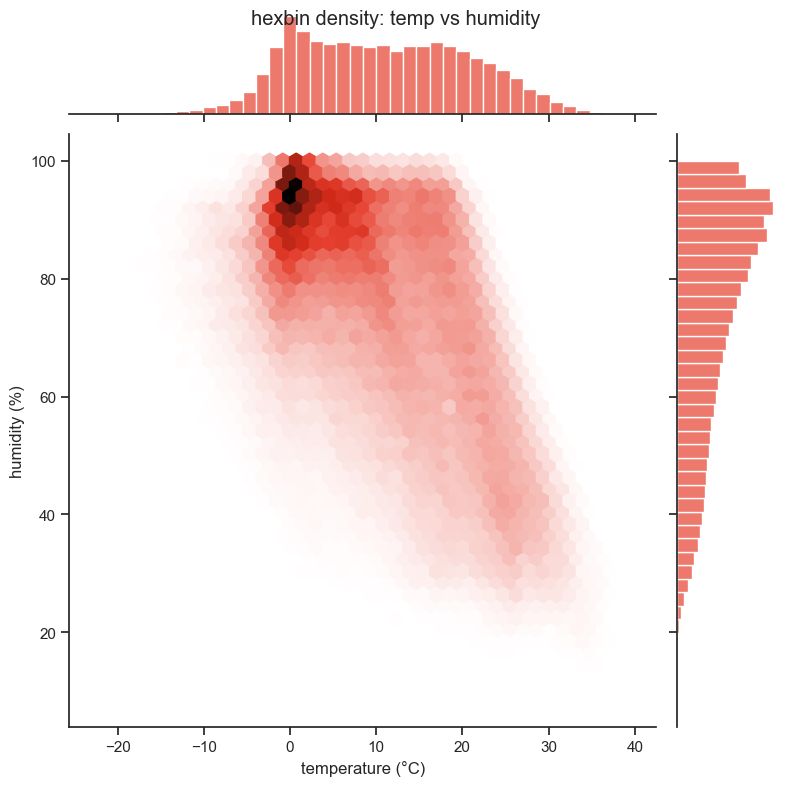

In [12]:
sns.set_theme(style="ticks")

g = sns.jointplot(
    data=weather, 
    x="hour_temp", 
    y="hour_humidity", 
    kind="hex", 
    color="#e74c3c", 
    gridsize=40, 
    height=8,
    marginal_kws=dict(bins=40, fill=True)
)

g.fig.suptitle("hexbin density: temp vs humidity")
g.set_axis_labels("temperature (°C)", "humidity (%)")
plt.show()

- High density of high humidity values.

## Climate wheel

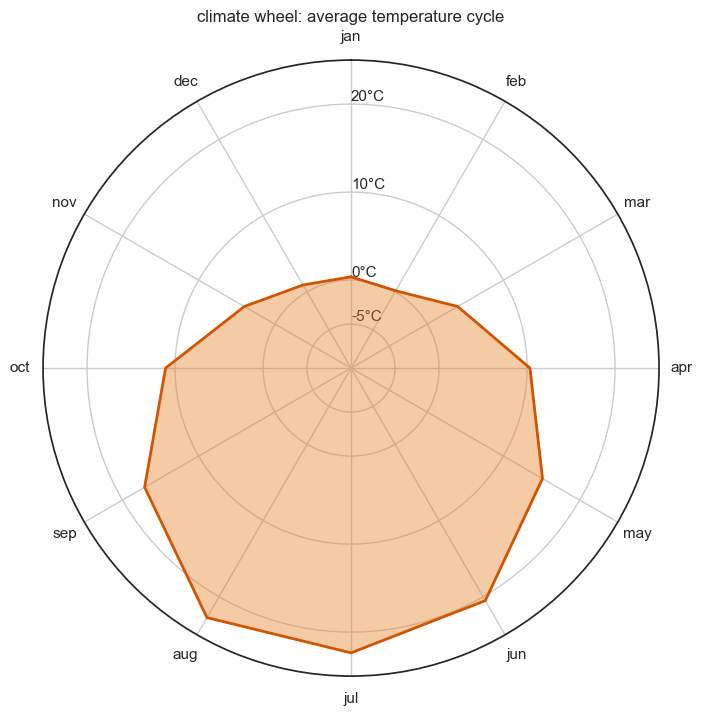

In [13]:
monthly_t = weather.groupby(weather['day_datetime'].dt.month)['hour_temp'].mean().reset_index()

months = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
values = monthly_t['hour_temp'].tolist()
values += values[:1]

angles = [n / float(12) * 2 * np.pi for n in range(12)]
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], months)

ax.set_rlabel_position(0)
plt.yticks([-5, 0, 10, 20], ["-5°C", "0°C", "10°C", "20°C"], )
plt.ylim(-10, 25)

ax.plot(angles, values, color='#d35400', linewidth=2, linestyle='solid')
ax.fill(angles, values, color='#e67e22', alpha=0.4)

plt.title("climate wheel: average temperature cycle")
plt.show()

## Weather conditions proportion

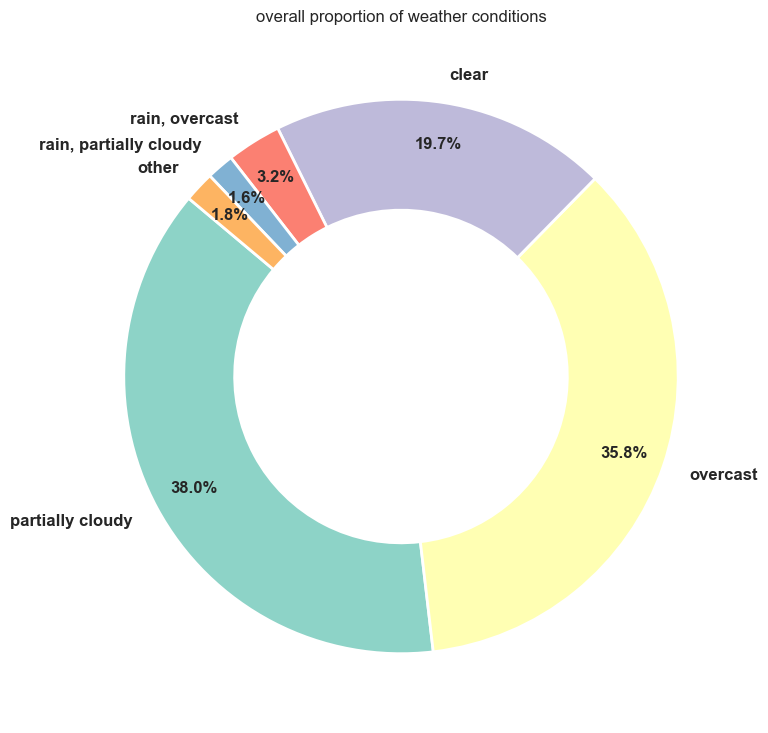

In [14]:
cond_counts = weather['hour_conditions'].value_counts()
top_cond = cond_counts.head(5).copy()
top_cond['other'] = cond_counts[5:].sum()
top_cond.index = top_cond.index.str.lower()

plt.figure(figsize=(9, 9))
colors = sns.color_palette("Set3")[0:len(top_cond)]

plt.pie(
    top_cond, 
    labels=top_cond.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    pctdistance=0.85, 
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
)

plt.title("overall proportion of weather conditions")
plt.show()

## Weather conditions breakdown by month

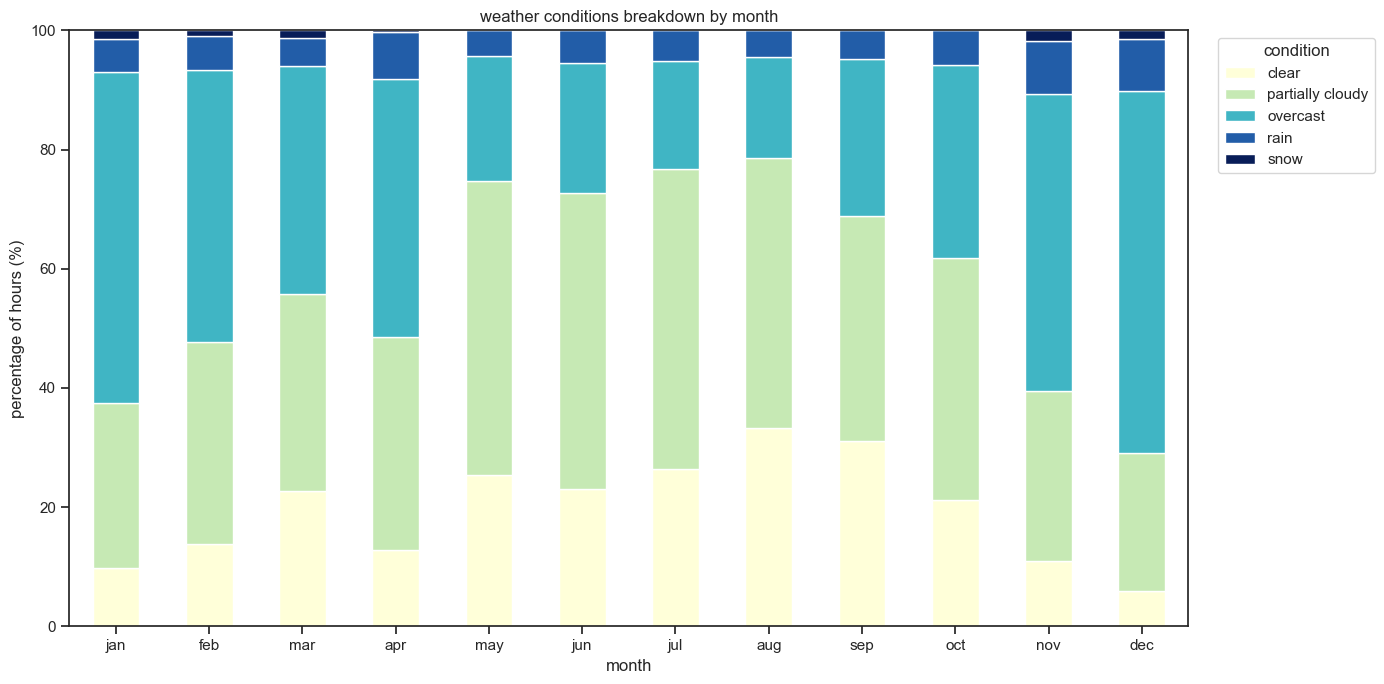

In [15]:
def simplify_condition(cond):
    c = str(cond).lower()
    if 'rain' in c or 'drizzle' in c: return 'rain'
    if 'snow' in c or 'ice' in c: return 'snow'
    if 'clear' in c: return 'clear'
    if 'partially cloudy' in c: return 'partially cloudy'
    if 'overcast' in c: return 'overcast'
    return 'other'

weather['simple_cond'] = weather['hour_conditions'].apply(simplify_condition)

monthly_cond = weather.groupby(['month', 'simple_cond']).size().unstack(fill_value=0)
monthly_cond_pct = monthly_cond.div(monthly_cond.sum(axis=1), axis=0) * 100

cols_order = ['clear', 'partially cloudy', 'overcast', 'rain', 'snow', 'other']
cols_order = [c for c in cols_order if c in monthly_cond_pct.columns]
monthly_cond_pct = monthly_cond_pct[cols_order]

ax = monthly_cond_pct.plot(
    kind='bar', 
    stacked=True, 
    figsize=(14, 7), 
    colormap='YlGnBu', 
    edgecolor='white',
    linewidth=1
)

plt.title("weather conditions breakdown by month")
plt.xlabel("month")
plt.ylabel("percentage of hours (%)")
plt.xticks(range(0, 12), ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'], rotation=0)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="condition")
plt.tight_layout()
plt.show()

- Significant increasement in snow during winter months.
- Clear weather is more frequent during summer.

# Data Preparation
## What I already did in EDA
- Filtered extreme temperature anomalies (removed outliers > 50°C and < -40°C)
- Combined day and hour into a single precise datetime column `real_hour_datetime`
- Cleaned city names from redundant commas
- Filled missing weather conditions with 'unknown'
- Created a simplified condition column `simple_cond` for better visual grouping

Check exact number of duplicates

In [16]:
print(f"Number of duplicates: {weather.duplicated(subset=['city_clean', 'real_hour_datetime']).sum()}")

Number of duplicates: 69


In [17]:
# removing duplicates
weather.drop_duplicates(
    subset=['city_clean', 'real_hour_datetime'],
    keep="last",
    inplace=True
)
weather.shape

(608233, 70)

## Dropping unnecessary columns

In [18]:
weather.columns

Index(['city_latitude', 'city_longitude', 'city_resolvedAddress',
       'city_address', 'city_timezone', 'city_tzoffset', 'day_datetime',
       'day_datetimeEpoch', 'day_tempmax', 'day_tempmin', 'day_temp',
       'day_feelslikemax', 'day_feelslikemin', 'day_feelslike', 'day_dew',
       'day_humidity', 'day_precip', 'day_precipprob', 'day_precipcover',
       'day_snow', 'day_snowdepth', 'day_windgust', 'day_windspeed',
       'day_winddir', 'day_pressure', 'day_cloudcover', 'day_visibility',
       'day_solarradiation', 'day_solarenergy', 'day_uvindex', 'day_sunrise',
       'day_sunriseEpoch', 'day_sunset', 'day_sunsetEpoch', 'day_moonphase',
       'day_conditions', 'day_description', 'day_icon', 'day_source',
       'day_preciptype', 'day_stations', 'hour_datetime', 'hour_datetimeEpoch',
       'hour_temp', 'hour_feelslike', 'hour_humidity', 'hour_dew',
       'hour_precip', 'hour_precipprob', 'hour_snow', 'hour_snowdepth',
       'hour_preciptype', 'hour_windgust', 'hour_windsp

In [19]:
weather.head()

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunriseEpoch,day_sunset,day_sunsetEpoch,day_moonphase,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_preciptype,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations,real_hour_datetime,city_clean,month,month_name,simple_cond
0,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,2026-03-15 00:00:00,1645653600,2.4,-1.6,89.18,0.8,0.0,0.0,0.1,0.2,['snow'],31.3,15.5,275.6,1020.0,0.0,91.5,0.0,NaN,0.0,Overcast,snow,obs,remote,2022-02-24 00:00:00,Lutsk,2,february,overcast
1,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,2026-03-15 01:00:00,1645657200,2.4,-1.5,87.90,0.6,0.0,0.0,0.0,0.2,['snow'],27.7,14.8,280.3,1021.0,0.2,88.2,0.0,NaN,0.0,Partially cloudy,fog,obs,remote,2022-02-24 01:00:00,Lutsk,2,february,partially cloudy
2,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,2026-03-15 02:00:00,1645660800,2.9,-0.8,88.58,1.2,0.0,0.0,0.0,0.1,['snow'],29.2,14.4,310.0,1022.0,10.0,100.0,NaN,NaN,NaN,Overcast,cloudy,obs,33177099999,2022-02-24 02:00:00,Lutsk,2,february,overcast
3,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,2026-03-15 03:00:00,1645664400,2.3,-1.3,86.63,0.3,0.0,0.0,0.0,0.1,['snow'],23.8,13.3,295.1,1021.0,0.1,92.0,0.0,NaN,0.0,Overcast,fog,obs,remote,2022-02-24 03:00:00,Lutsk,2,february,overcast
4,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,2026-03-15 04:00:00,1645668000,1.9,-1.8,87.85,0.1,0.0,0.0,0.0,0.1,['snow'],24.5,13.3,305.8,1021.0,0.0,93.8,0.0,NaN,0.0,Overcast,cloudy,obs,remote,2022-02-24 04:00:00,Lutsk,2,february,overcast


In [23]:
weather["hour_preciptype"].unique()

<ArrowStringArray>
['['snow']', nan, '['rain']', '['rain', 'snow']', '['freezingrain']',
 '['ice']']
Length: 6, dtype: str

In [ ]:
cols_to_drop = [
    'city_latitude', 'city_longitude', 'city_resolvedAddress', 'city_address', 'city_timezone',
    'day_datetime', 'day_datetimeEpoch', 'day_tempmax', 'day_tempmin', 'day_temp',
    'day_feelslikemax', 'day_feelslikemin', 'day_feelslike', 'day_dew',
    'day_humidity', 'day_precip', 'day_precipprob', 'day_precipcover',
    'day_snow', 'day_snowdepth', 'day_windgust', 'day_windspeed',
    'day_winddir', 'day_pressure', 'day_cloudcover', 'day_visibility',
    'day_solarradiation', 'day_solarenergy', 'day_uvindex', 'day_sunrise',
    'day_sunriseEpoch', 'day_sunset', 'day_sunsetEpoch', 'day_moonphase',
    'day_conditions', 'day_description', 'day_icon', 'day_source',
    'day_preciptype', 'day_stations', 'hour_icon', 'simple_cond', 
    'hour_datetimeEpoch', 'hour_datetime', 'hour_solarenergy', 'hour_solarradiation',
    'hour_windgust', 'hour_snowdepth', 'hour_snow', 'hour_snowdepth', 'city_tzoffset',
    'month_name', "month", 'hour_source', 'hour_stations'
]

weather = weather.drop(cols_to_drop, axis='columns')

In [30]:
weather.rename({"city_clean": "city"}, axis=1, inplace=True)

# Saving data

In [31]:
save_path = Path("data/weather/weather_data_preprocessed_v2.csv")

weather.to_csv(save_path, index=False)